
# Talabat Late Delivery Risk Prediction (Classification + Regression)

**Project:** Predict whether an order will be delayed and estimate delay minutes (ETA deviation).  
**Dataset:** Talabat orders (Excel)  
**Outputs:**
1. **Classification model:** Predicts `Delayed` (Yes/No)
2. **Regression model:** Predicts `Mins` (Exact minutes late)


In [ ]:
# Install dependencies
!pip -q install openpyxl scikit-learn matplotlib numpy pandas

# Optional: Uncomment if you plan to use advanced boosting models later
# !pip -q install xgboost catboost shap

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [ ]:
# ===== LOAD DATA SECTION =====
# NOTE: Make sure to upload your 'Talabat Excel.xlsx' file to the Colab Files area

import os
import pandas as pd
from IPython.display import display

# Define the path
excel_path = "/content/Talabat Excel.xlsx"

# Check if file exists
if not os.path.exists(excel_path):
    print(f"⚠️ File not found at {excel_path}.")
    print("Please click the 'Files' icon on the left -> Upload your Excel file.")
    from google.colab import files
    uploaded = files.upload()
    excel_path = list(uploaded.keys())[0]

# Load Excel File
try:
    xls = pd.ExcelFile(excel_path)
    print("Available Sheets:", xls.sheet_names)

    target_sheet = "MA"

    if target_sheet in xls.sheet_names:
        print(f"Loading sheet: {target_sheet}")
        df = pd.read_excel(excel_path, sheet_name=target_sheet)
        display(df.head())
    else:
        print(f"❌ Error: Sheet '{target_sheet}' not found. Available sheets: {xls.sheet_names}")

except Exception as e:
    print("Error loading file:", e)

Available Sheets: ['Glossary', 'PN', 'Sheet3', 'Pivot Table 2', 'MA', 'Sheet2', 'Pivot Table 3', 'Projected Order Volume']
Loading sheet: MA


,Order ID,Country Code,Contact By,Promised Delivery Time,Updated Promised Delivery Time,Updated Actual Delivery Time,Actual Delivery Time,Agent contacted?,Agent Contact Reason,Customer Account ID,Is Compensated?,Is Food Order?,Order Status,Is Modified?,Mins,Compensation,Group-mins,Delayed
0,4544054,MA,Rider,1986-03 20:39:00.000000,20:39:00,20:39:04,1986-03 20:39:46.914000,Yes,Other,2036621T,NO,Yes,SUCCESS,No,0.066667,0,0-10 mins,On Time
1,9953061,MA,NaN,1986-03 20:40:00.000000,20:40:00,20:44:03,1986-03 20:44:35.682000,No,,1642549K,NO,Yes,SUCCESS,No,4.050000,0,0-10 mins,On Time
2,9669472,MA,NaN,1986-03 20:18:00.000000,20:18:00,20:12:23,1986-03 20:12:23.249000,No,,3906918W,NO,No,SUCCESS,No,-5.616667,0,Before Time,On Time
3,3485574,MA,NaN,NaN,NaN,NaN,NaN,No,,6411415J,NO,Yes,FAILED,No,NaN,0,NaN,NaN
4,3967641,MA,NaN,1986-03 20:31:00.000000,20:31:00,20:45:07,1986-03 20:45:07.532000,No,,1703770Q,NO,Yes,SUCCESS,No,14.116667,15,10-20 mins,Delayed


In [ ]:
# Basic sanity checks
print("Shape:", df.shape)
df.info()

# Transpose describe for better readability
display(df.describe(include="all").T)

Shape: (50000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Order ID                        50000 non-null  int64  
 1   Country Code                    50000 non-null  object 
 2   Contact By                      5071 non-null   object 
 3   Promised Delivery Time          40348 non-null  object 
 4   Updated Promised Delivery Time  40348 non-null  object 
 5   Updated Actual Delivery Time    37488 non-null  object 
 6   Actual Delivery Time            37488 non-null  object 
 7   Agent contacted?                50000 non-null  object 
 8   Agent Contact Reason            50000 non-null  object 
 9   Customer Account ID             50000 non-null  object 
 10  Is Compensated?                 50000 non-null  object 
 11  Is Food Order?                  50000 non-null  object 
 12  Order Status 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order ID,50000.0,NaN,NaN,NaN,6249235.40036,3323414.675075,500134.0,3352951.5,6276976.0,9115604.0,11999421.0
Country Code,50000,1,MA,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contact By,5071,3,Rider,2560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promised Delivery Time,40348,17078,1986-03 20:57:35.000000,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Updated Promised Delivery Time,40348,17077,20:57:35,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Updated Actual Delivery Time,37488,16800,21:07:40,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actual Delivery Time,37488,36828,1986-03 21:31:56.319000,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent contacted?,50000,2,No,44929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent Contact Reason,50000,17,,44929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Account ID,50000,49993,3874091Y,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

### Setting up Target Variables

In [ ]:
# Print columns to help identify correct names
print("Columns in dataset:", df.columns.tolist())

# TODO: Update these variables to match your actual Excel column headers
COL_MINS = "Mins"           # The column containing numeric delay minutes
COL_DELAYED = "Delayed"     # The binary column (0/1 or Yes/No)

# Logic: If 'Delayed' column doesn't exist, create it based on 'Mins'
DELAY_THRESHOLD = 10  # Orders > 10 mins late are flagged as delayed

if COL_DELAYED not in df.columns and COL_MINS in df.columns:
    print(f"Creating '{COL_DELAYED}' column based on threshold > {DELAY_THRESHOLD} mins.")
    df[COL_DELAYED] = (df[COL_MINS] > DELAY_THRESHOLD).astype(int)
    COL_DELAYED = "Delayed"

# Verify targets
if COL_DELAYED in df.columns and COL_MINS in df.columns:
    display(df[[COL_DELAYED, COL_MINS]].head())
else:
    print("⚠️ Warning: Target columns not found. Please check column names above.")

Columns in dataset: ['Order ID', 'Country Code', 'Contact By', 'Promised Delivery Time', 'Updated Promised Delivery Time', 'Updated Actual Delivery Time', 'Actual Delivery Time', 'Agent contacted?', 'Agent Contact Reason', 'Customer Account ID', 'Is Compensated?', 'Is Food Order?', 'Order Status', 'Is Modified?', 'Mins', 'Compensation', 'Group-mins', 'Delayed']


,Delayed,Mins
0,On Time,0.066667
1,On Time,4.050000
2,On Time,-5.616667
3,NaN,NaN
4,Delayed,14.116667


---

## SECTION 1 - DATA CLEANING AND FEATURE ENGINEERING

Clean the data:
1. Standardize column names
2. Fix null values
3. Drop duplicates
4. Handle missing values in the target columns
5. Handle anything else that seems apt for our problem statement

In [ ]:
import pandas as pd
import numpy as np

# To keep track of changes for final summary:
removed_columns = []
added_columns = []
rows_removed = 0

1. STANDARDIZE COLUMN NAMES

In [ ]:
# This makes column names consistent and Python-friendly & avoids errors when referencing columns later.

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

print("Step 1 - Columns standardized.")
print("Columns:", df.columns.tolist())
print("Dataset shape:", df.shape)

Step 1 - Columns standardized.
Columns: ['order_id', 'country_code', 'contact_by', 'promised_delivery_time', 'updated_promised_delivery_time', 'updated_actual_delivery_time', 'actual_delivery_time', 'agent_contacted?', 'agent_contact_reason', 'customer_account_id', 'is_compensated?', 'is_food_order?', 'order_status', 'is_modified?', 'mins', 'compensation', 'group_mins', 'delayed']
Dataset shape: (50000, 18)


2. FIX NULL VALUES

In [ ]:
# Step 2a: Check missing values:
# This sees which columns have missing data and how much & helps decide which columns to drop or fill.

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="Missing_Percentage", ascending=False)

print("\nStep 2a - Missing value summary (only >0):")
display(missing_summary[missing_summary["Missing_Count"] > 0])


Step 2a - Missing value summary (only >0):


,Missing_Count,Missing_Percentage
contact_by,44929,89.858
delayed,12780,25.560
mins,12512,25.024
group_mins,12512,25.024
actual_delivery_time,12512,25.024
updated_actual_delivery_time,12512,25.024
updated_promised_delivery_time,9652,19.304
promised_delivery_time,9652,19.304


In [ ]:
# Step 2b: Drop columns with >50% missing:
# Because columns with too many missing values are less informative & reduces noise and simplifies dataset.

high_missing_cols = missing_summary[missing_summary["Missing_Percentage"] > 50].index.tolist()
df.drop(columns=high_missing_cols, inplace=True)
removed_columns.extend(high_missing_cols)

print(f"\nStep 2b - Dropped columns with >50% missing: {high_missing_cols}")
print("Shape after dropping high missing columns:", df.shape)


Step 2b - Dropped columns with >50% missing: ['contact_by']
Shape after dropping high missing columns: (50000, 17)


In [ ]:
# Step 2c: Fill numeric columns with median:
# Because median is robust to outliers & ensures numeric columns have no missing values.

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Step 2c - Numeric missing values filled with median.")

Step 2c - Numeric missing values filled with median.


In [ ]:
# Step 2d: Fill categorical columns with "Unknown":
# This keeps categorical columns complete & "Unknown" is a safe placeholder for missing categories.

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("Unknown")

print("Step 2d - Categorical missing values filled with 'Unknown'.")
print("Shape after null handling:", df.shape)

Step 2d - Categorical missing values filled with 'Unknown'.
Shape after null handling: (50000, 17)


3. DROP DUPLICATES

In [ ]:
# This removes exact duplicate rows, which do not add information & keeps dataset clean and unique.

num_duplicates = df.duplicated().sum()
print("Step 3a - Number of duplicate rows:", num_duplicates)

Step 3a - Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
rows_removed += num_duplicates
print("Step 3b - Dataset shape after dropping duplicates:", df.shape)

Step 3b - Dataset shape after dropping duplicates: (50000, 17)


4. HANDLE MISSING VALUES IN THE TARGET COLUMNS

In [ ]:
# Bacause targets must be numeric and complete for modeling & drops rows where the target is missing.

COL_MINS = "mins"
COL_DELAYED = "delayed"

# Clean delayed column: lowercase, strip spaces
df[COL_DELAYED] = df[COL_DELAYED].astype(str).str.strip().str.lower()

In [ ]:
# Map delayed to binary
delay_mapping = {"delayed": 1, "on time": 0}
df[COL_DELAYED] = df[COL_DELAYED].map(delay_mapping)

In [ ]:
# Drop rows where targets are missing
before_rows = df.shape[0]
df = df.dropna(subset=[COL_MINS, COL_DELAYED])
after_rows = df.shape[0]
rows_removed += before_rows - after_rows

df[COL_DELAYED] = df[COL_DELAYED].astype(int)

print(f"\nStep 4 - Dropped {before_rows - after_rows} rows due to missing target values.")
print("Step 4 - Target distribution (proportion):")
display(df[COL_DELAYED].value_counts(normalize=True))
print("Shape after handling targets:", df.shape)


Step 4 - Dropped 12780 rows due to missing target values.
Step 4 - Target distribution (proportion):


,proportion
delayed,
0,0.775712
1,0.224288


Shape after handling targets: (37220, 17)


5. HANDLE ANYTHING ELSE THAT SEEMS APT FOR OUR PROBLEM STATEMENT

In [ ]:
# Step 5a: Remove potential data leakage columns:
# This prevents data leakage, i.e., using future information to predict the target.

leakage_cols = [
    "actual_delivery_time",
    "updated_actual_delivery_time",
    "updated_promised_delivery_time",
    "group_mins",
    "compensation",
    "is_compensated?"
]
df.drop(columns=leakage_cols, inplace=True, errors="ignore")
removed_columns.extend(leakage_cols)

print(f"Step 5a - Dropped leakage columns: {leakage_cols}")
print("Shape after dropping leakage columns:", df.shape)

Step 5a - Dropped leakage columns: ['actual_delivery_time', 'updated_actual_delivery_time', 'updated_promised_delivery_time', 'group_mins', 'compensation', 'is_compensated?']
Shape after dropping leakage columns: (37220, 11)


In [ ]:
# Step 5b: Convert datetime properly:
# Converts strings to datetime for feature creation & drops rows with invalid timestamps.

df["promised_delivery_time"] = pd.to_datetime(df["promised_delivery_time"], errors="coerce")

# Drop rows with invalid datetime
before_rows = df.shape[0]
df = df.dropna(subset=["promised_delivery_time"])
after_rows = df.shape[0]
rows_removed += before_rows - after_rows

print(f"Step 5b - Converted promised_delivery_time to datetime and dropped {before_rows - after_rows} invalid rows.")
print("Missing promised_delivery_time:", df["promised_delivery_time"].isnull().sum())

/tmp/ipykernel_293/1774640673.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["promised_delivery_time"] = pd.to_datetime(df["promised_delivery_time"], errors="coerce")


Step 5b - Converted promised_delivery_time to datetime and dropped 0 invalid rows.
Missing promised_delivery_time: 0


In [ ]:
# Step 5c: Create time-based features:
# This extracts meaningful features from datetime (hour, day, weekend, rush hour) & drops original datetime column to avoid leakage.

df["promised_hour"] = df["promised_delivery_time"].dt.hour
df["promised_dayofweek"] = df["promised_delivery_time"].dt.dayofweek
df["is_weekend"] = df["promised_dayofweek"].apply(lambda x: 1 if x >= 5 else 0)
df["is_rush_hour"] = df["promised_hour"].apply(lambda x: 1 if (12 <= x <= 14) or (18 <= x <= 21) else 0)
added_columns.extend(["promised_hour", "promised_dayofweek", "is_weekend", "is_rush_hour"])

print("Step 5c - Time features created.")

# Drop raw datetime
df.drop(columns=["promised_delivery_time"], inplace=True)
removed_columns.append("promised_delivery_time")
print("Shape after dropping raw datetime column:", df.shape)

Step 5c - Time features created.
Shape after dropping raw datetime column: (37220, 14)


In [ ]:
# Step 5d: Fill remaining numeric/categorical missing values:
# This ensures no missing values remain.

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in [COL_MINS, COL_DELAYED]]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Step 5d - Remaining feature missing values handled.")
print("Shape after feature missing handling:", df.shape)

Step 5d - Remaining feature missing values handled.
Shape after feature missing handling: (37220, 14)


In [ ]:
# Step 5e: Drop ID columns:
# Because IDs are unique identifiers & not useful for modeling and may cause overfitting.

id_cols = ["order_id", "customer_account_id"]
df.drop(columns=id_cols, inplace=True, errors="ignore")
removed_columns.extend(id_cols)

print(f"Step 5e - Dropped ID columns: {id_cols}")
print("Shape after dropping ID columns:", df.shape)

Step 5e - Dropped ID columns: ['order_id', 'customer_account_id']
Shape after dropping ID columns: (37220, 12)


In [ ]:
# Step 5f: Handle outliers in mins:
# This caps extreme outliers in the target (mins) using the IQR method & helps stabilize regression models.

Q1 = df[COL_MINS].quantile(0.25)
Q3 = df[COL_MINS].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[COL_MINS] = np.where(df[COL_MINS] < lower_bound, lower_bound, df[COL_MINS])
df[COL_MINS] = np.where(df[COL_MINS] > upper_bound, upper_bound, df[COL_MINS])

print("Step 5f - Outliers in mins capped.")
print("Final dataset shape:", df.shape)

Step 5f - Outliers in mins capped.
Final dataset shape: (37220, 12)


> FINAL SANITY CHECK

In [ ]:
# This confirms dataset is clean and ready for modeling.

print("\nRemaining missing values (if any):")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nTarget distribution (proportion):")
display(df[COL_DELAYED].value_counts(normalize=True))

print("\nPreview of dataset:")
display(df.head())


Remaining missing values (if any):
Series([], dtype: int64)

Target distribution (proportion):


,proportion
delayed,
0,0.775712
1,0.224288



Preview of dataset:


,country_code,agent_contacted?,agent_contact_reason,is_food_order?,order_status,is_modified?,mins,delayed,promised_hour,promised_dayofweek,is_weekend,is_rush_hour
0,MA,Yes,Other,Yes,SUCCESS,No,0.066667,0,20,5,1,1
1,MA,No,,Yes,SUCCESS,No,4.050000,0,20,5,1,1
2,MA,No,,No,SUCCESS,No,-5.616667,0,20,5,1,1
4,MA,No,,Yes,SUCCESS,No,14.116667,1,20,5,1,1
6,MA,No,,Yes,SUCCESS,No,-0.850000,0,20,5,1,1


> SUMMARY TABLE

In [ ]:
# This keeps a log of all changes for documentation & shows which columns were removed, features added, and rows removed.

removed_columns_unique = list(dict.fromkeys(removed_columns))

summary = pd.DataFrame({
    "Columns_Removed": removed_columns_unique,
    "Columns_Added": [added_columns]*len(removed_columns_unique),
    "Rows_Removed": [rows_removed]*len(removed_columns_unique)
})

print("\nSUMMARY OF CLEANING STEPS:")
display(summary)


SUMMARY OF CLEANING STEPS:


,Columns_Removed,Columns_Added,Rows_Removed
0,contact_by,"[promised_hour, promised_dayofweek, is_weekend...",12780
1,actual_delivery_time,"[promised_hour, promised_dayofweek, is_weekend...",12780
2,updated_actual_delivery_time,"[promised_hour, promised_dayofweek, is_weekend...",12780
3,updated_promised_delivery_time,"[promised_hour, promised_dayofweek, is_weekend...",12780
4,group_mins,"[promised_hour, promised_dayofweek, is_weekend...",12780
5,compensation,"[promised_hour, promised_dayofweek, is_weekend...",12780
6,is_compensated?,"[promised_hour, promised_dayofweek, is_weekend...",12780
7,promised_delivery_time,"[promised_hour, promised_dayofweek, is_weekend...",12780
8,order_id,"[promised_hour, promised_dayofweek, is_weekend...",12780
9,customer_account_id,"[promised_hour, promised_dayofweek, is_weekend...",12780


## SECTION 2 - FEATURE ENCODING AND ENGINEERING
create a pipeline - encode categorical with OneHotEncoding and Scale Numerical cols with a scaler

In [ ]:
df = df.drop(columns=['agent_contacted?', 'agent_contact_reason'])

In [ ]:
print("Identifying features and targets...")

# Identify all column names in the df DataFrame
all_columns = df.columns.tolist()

# Create a list of feature columns by excluding the target columns
feature_columns = [col for col in all_columns if col not in [COL_MINS, COL_DELAYED]]

# X and y for classification
X_cls = df[feature_columns].copy()
y_cls = df[COL_DELAYED].copy()

print(f"Features (X_cls) shape: {X_cls.shape}")
print(f"Classification target (y_cls) shape: {y_cls.shape}")

Identifying features and targets...
Features (X_cls) shape: (37220, 8)
Classification target (y_cls) shape: (37220,)


In [ ]:
print("Filtering 'df' for delayed orders...")

# Filter the df DataFrame to select only the rows where the value in the 'delayed' column is equal to 1.
df_delayed = df[df[COL_DELAYED] == 1].copy()

print(f"Successfully filtered 'df'. New DataFrame 'df_delayed' created with shape: {df_delayed.shape}")

# X and y for regression
X_reg = df_delayed[feature_columns].copy()
y_reg = df_delayed[COL_MINS].copy() - DELAY_THRESHOLD


# Print the shape (number of rows and columns)
print(f"Features (X_reg) shape: {X_reg.shape}")
print(f"Classification target (y_reg) shape: {y_reg.shape}")

Filtering 'df' for delayed orders...
Successfully filtered 'df'. New DataFrame 'df_delayed' created with shape: (8348, 10)
Features (X_reg) shape: (8348, 8)
Classification target (y_reg) shape: (8348,)


### Train Test Split

In [ ]:
print("Step 2 - Splitting data into training and testing sets...")

# Split data for classification
X_train_cls_ut, X_test_cls_ut, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Split data for regression
X_train_reg_ut, X_test_reg_ut, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Data split successfully.")

# Print shapes to confirm
print(f"\nShape of X_train_cls: {X_train_cls_ut.shape}")
print(f"Shape of X_test_cls: {X_test_cls_ut.shape}")
print(f"Shape of y_train_cls: {y_train_cls.shape}")
print(f"Shape of y_test_cls: {y_test_cls.shape}")
print(f"\nShape of X_train_reg: {X_train_reg_ut.shape}")
print(f"Shape of X_test_reg: {X_test_reg_ut.shape}")
print(f"Shape of y_train_reg: {y_train_reg.shape}")
print(f"Shape of y_test_reg: {y_test_reg.shape}")

Step 2 - Splitting data into training and testing sets...
Data split successfully.

Shape of X_train_cls: (29776, 8)
Shape of X_test_cls: (7444, 8)
Shape of y_train_cls: (29776,)
Shape of y_test_cls: (7444,)

Shape of X_train_reg: (6678, 8)
Shape of X_test_reg: (1670, 8)
Shape of y_train_reg: (6678,)
Shape of y_test_reg: (1670,)


### Column Transformation

In [ ]:
# Defining Numerical and Categorical Features
numerical_features = X_train_cls_ut.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_cls_ut.select_dtypes(include=["object"]).columns.tolist()

numerical_features_delayed = X_train_reg_ut.select_dtypes(include=["int64", "float64"]).columns
categorical_features_delayed = X_train_reg_ut.select_dtypes(include=["object"]).columns

In [ ]:
print("Creating separate preprocessors with OneHotEncoder and StandardScaler...")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical features
numerical_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer for Classification (using original features)
preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a column transformer for Regression on Delayed Orders (using delayed features)
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_delayed),
        ('cat', categorical_transformer, categorical_features_delayed)
    ])

print("Separate preprocessor objects (preprocessor_cls, preprocessor_reg) created.")


Creating separate preprocessors with OneHotEncoder and StandardScaler...
Separate preprocessor objects (preprocessor_cls, preprocessor_reg) created.


In [ ]:
print("Applying preprocessing pipeline to classification features...")

X_train_cls = preprocessor_cls.fit_transform(X_train_cls_ut)
X_test_cls = preprocessor_cls.transform(X_test_cls_ut)

print("Classification features successfully preprocessed (fit on training, transformed on train/test).")


Applying preprocessing pipeline to classification features...
Classification features successfully preprocessed (fit on training, transformed on train/test).


In [ ]:
print("Applying preprocessing pipeline to regression features...")

X_train_reg = preprocessor_reg.fit_transform(X_train_reg_ut)
X_test_reg = preprocessor_reg.transform(X_test_reg_ut)

print("Regression features successfully preprocessed (fit on training, transformed on train/test).")


Applying preprocessing pipeline to regression features...
Regression features successfully preprocessed (fit on training, transformed on train/test).


---

## SECTION 3 - TRAIN CLASSIFICATION MODEL

Try different classification models (try atleast 3 classification models discussed in the lectures)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


### Logistic Regression


In [ ]:
print("Logistic Regression")

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_cls, y_train_cls)

y_pred_log = log_model.predict(X_test_cls)

acc_log = accuracy_score(y_test_cls, y_pred_log)

print("Accuracy:", acc_log)


Logistic Regression
Accuracy: 0.5006716818914562


### Random Forest

In [ ]:
print("\nTraining Random Forest")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_cls, y_train_cls)

y_pred_rf = rf_model.predict(X_test_cls)

acc_rf = accuracy_score(y_test_cls, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)


Training Random Forest
Random Forest Accuracy: 0.5076571735626008


### Naive Bayes

In [ ]:
print("\nNaive Bayes")

nb_model = GaussianNB()

nb_model.fit(X_train_cls, y_train_cls)

y_pred_nb = nb_model.predict(X_test_cls)

acc_nb = accuracy_score(y_test_cls, y_pred_nb)

print("Accuracy: ", acc_nb)


Naive Bayes
Accuracy:  0.7634336378291241


### KNN

In [ ]:
print("Training KNN")

scaler = StandardScaler(with_mean=False)

X_train_knn = scaler.fit_transform(X_train_cls)
X_test_knn = scaler.transform(X_test_cls)

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_knn, y_train_cls)

y_pred_knn = knn_model.predict(X_test_knn)

acc_knn = accuracy_score(y_test_cls, y_pred_knn)

print("KNN Accuracy:", acc_knn)

Training KNN
KNN Accuracy: 0.7756582482536271


### Comparison of all the models

In [ ]:
print("\nModel Comparison:")
print("Logistic Regression Accuracy:", acc_log)
print("Random Forest Accuracy:", acc_rf)
print("Naive Bayes Accuracy:", acc_nb)
print("KNN Accuracy:", acc_knn)


Model Comparison:
Logistic Regression Accuracy: 0.5006716818914562
Random Forest Accuracy: 0.5076571735626008
Naive Bayes Accuracy: 0.7634336378291241
KNN Accuracy: 0.7756582482536271


## Evaluation Metrics

### Confusion Matrix- Logistics Regression, Random Forest, Naive Bayes, KNN




Logistic Regression Evaluation
Accuracy : 0.5007
Precision: 0.2394
Recall   : 0.5629
F1 Score : 0.3359

Confusion Matrix:
[[2787 2987]
 [ 730  940]]


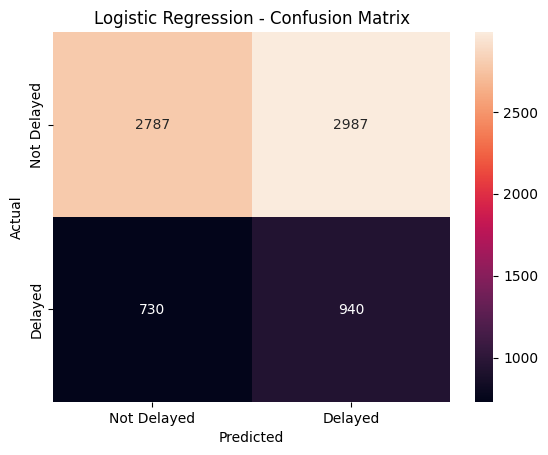

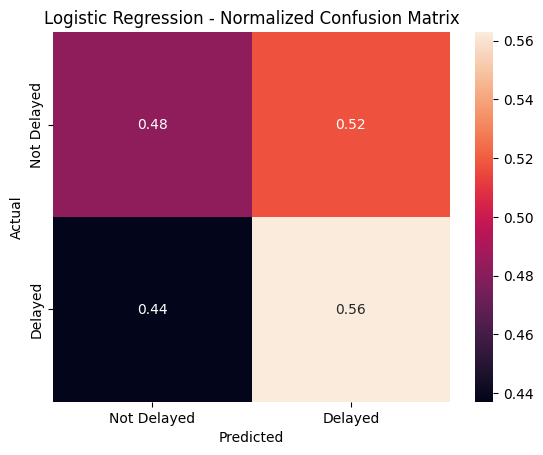


Random Forest Evaluation
Accuracy : 0.5077
Precision: 0.2444
Recall   : 0.5713
F1 Score : 0.3424

Confusion Matrix:
[[2825 2949]
 [ 716  954]]


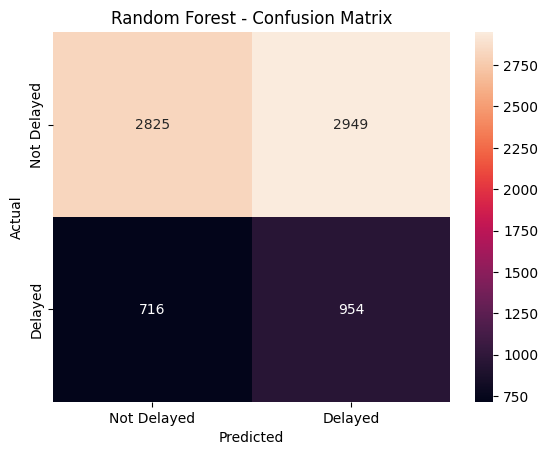

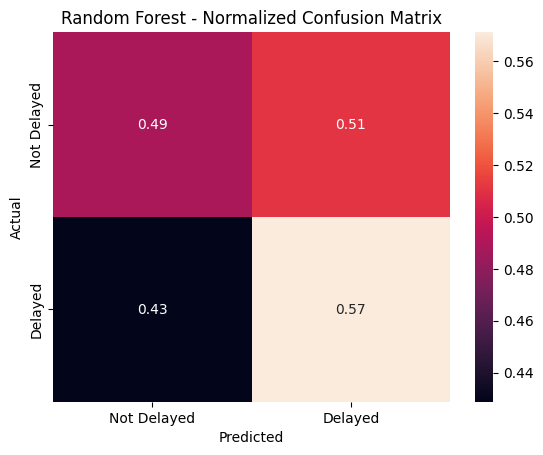


Naive Bayes Evaluation
Accuracy : 0.7634
Precision: 0.3270
Recall   : 0.0515
F1 Score : 0.0890

Confusion Matrix:
[[5597  177]
 [1584   86]]


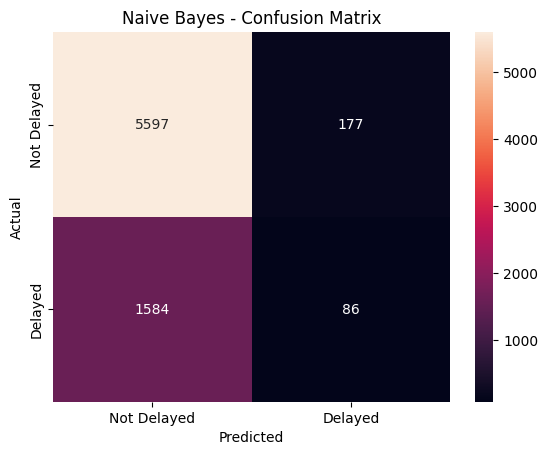

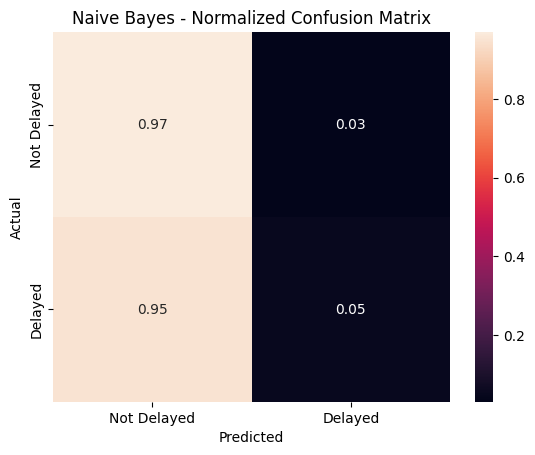


KNN Evaluation
Accuracy : 0.7757
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Confusion Matrix:
[[5774    0]
 [1670    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


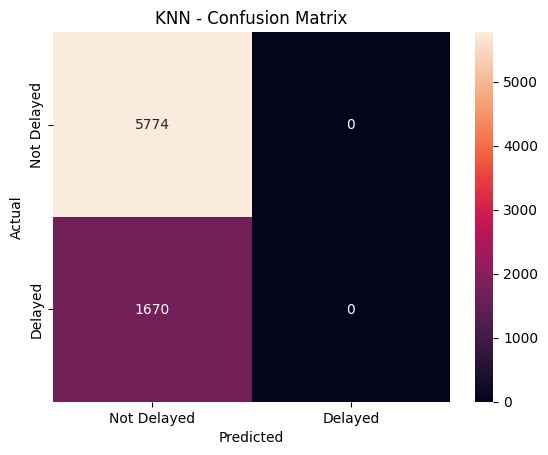

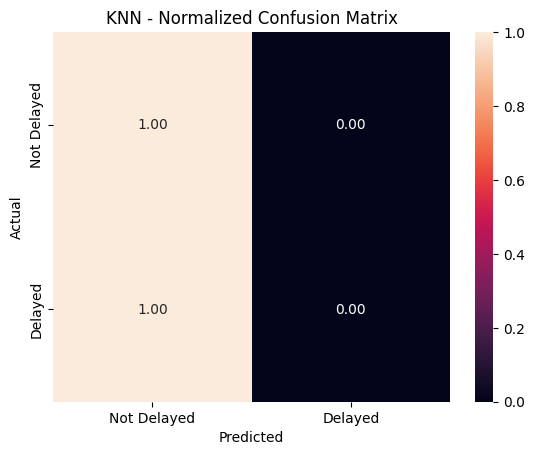

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Store predictions
models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb,
    "KNN": y_pred_knn
}

for name, y_pred in models.items():

    print("\n" + "="*60)
    print(f"{name} Evaluation")
    print("="*60)

    # Metrics
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Confusion Matrix (raw numbers)
    cm = confusion_matrix(y_test_cls, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Heatmap (Raw)
    plt.figure()
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                xticklabels=["Not Delayed", "Delayed"],
                yticklabels=["Not Delayed", "Delayed"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Normalized Confusion Matrix (Percentages)
    cm_norm = confusion_matrix(y_test_cls, y_pred, normalize="true")

    plt.figure()
    sns.heatmap(cm_norm,
                annot=True,
                fmt=".2f",
                xticklabels=["Not Delayed", "Delayed"],
                yticklabels=["Not Delayed", "Delayed"])
    plt.title(f"{name} - Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

---

## SECTION 4 - TRAIN REGRESSION MODEL

Try different regression models and see which one works the best

### Import Regression Models and Metrics

Import all necessary regression models (`LinearRegression`, `ElasticNet`, `RandomForestRegressor`, `XGBRegressor`) and evaluation metrics (`mean_absolute_error`, `mean_squared_error`, `r2_score`) from `sklearn` and `xgboost`.


In [ ]:
print("Importing regression models and metrics...")

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Optional: Import XGBoost if installed
try:
    from xgboost import XGBRegressor
    print("XGBoost imported.")
except ImportError:
    print("XGBoost not installed. Skipping import.")
    XGBRegressor = None

print("Regression models and metrics imported successfully.")

Importing regression models and metrics...
XGBoost imported.
Regression models and metrics imported successfully.


### Linear Regression

In [ ]:
print("Training Linear Regression model...")

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_linear_reg = linear_reg_model.predict(X_test_reg)

# Evaluate the model
mae_linear_reg = mean_absolute_error(y_test_reg, y_pred_linear_reg)
mse_linear_reg = mean_squared_error(y_test_reg, y_pred_linear_reg)
rmse_linear_reg = np.sqrt(mse_linear_reg)
r2_linear_reg = r2_score(y_test_reg, y_pred_linear_reg)

print("\nLinear Regression Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_linear_reg:.4f}")
print(f"  Mean Squared Error (MSE): {mse_linear_reg:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_linear_reg:.4f}")
print(f"  R-squared (R2): {r2_linear_reg:.4f}")


Training Linear Regression model...

Linear Regression Model Evaluation:
  Mean Absolute Error (MAE): 5.0283
  Mean Squared Error (MSE): 31.4442
  Root Mean Squared Error (RMSE): 5.6075
  R-squared (R2): 0.0073


### Elastic Net

In [ ]:
print("Training Elastic Net model...")

from sklearn.model_selection import GridSearchCV

# Define the parameter grid for ElasticNet
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

}

# Initialize the Elastic Net model
elastic_net = ElasticNet(random_state=42)

print("Starting GridSearchCV for Elastic Net...")
# Initialize GridSearchCV
grid_search_elastic_net = GridSearchCV(elastic_net, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_elastic_net.fit(X_train_reg, y_train_reg)

# Get the best estimator
elastic_net_model = grid_search_elastic_net.best_estimator_

print(f"Best parameters for Elastic Net: {grid_search_elastic_net.best_params_}")

# Make predictions on the test set using the best model
y_pred_elastic_net = elastic_net_model.predict(X_test_reg)

# Evaluate the model
mae_elastic_net = mean_absolute_error(y_test_reg, y_pred_elastic_net)
mse_elastic_net = mean_squared_error(y_test_reg, y_pred_elastic_net)
rmse_elastic_net = np.sqrt(mse_elastic_net)
r2_elastic_net = r2_score(y_test_reg, y_pred_elastic_net)

print("\nElastic Net Model Evaluation (Fine-tuned):")
print(f"  Mean Absolute Error (MAE): {mae_elastic_net:.4f}")
print(f"  Mean Squared Error (MSE): {mse_elastic_net:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_elastic_net:.4f}")
print(f"  R-squared (R2): {r2_elastic_net:.4f}")

Training Elastic Net model...
Starting GridSearchCV for Elastic Net...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best parameters for Elastic Net: {'alpha': 0.01, 'l1_ratio': 0.1}

Elastic Net Model Evaluation (Fine-tuned):
  Mean Absolute Error (MAE): 5.0288
  Mean Squared Error (MSE): 31.4384
  Root Mean Squared Error (RMSE): 5.6070
  R-squared (R2): 0.0075


### Random Forest Regressor

In [ ]:
print("Training Random Forest Regressor model...")

from sklearn.model_selection import GridSearchCV

# Define a reduced parameter grid for basic fine-tuning
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor model
rf_reg = RandomForestRegressor(random_state=42)

print("Starting GridSearchCV for Random Forest Regressor...")
# Initialize GridSearchCV
grid_search_rf = GridSearchCV(rf_reg, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_reg, y_train_reg)

# Get the best estimator
rf_reg_model = grid_search_rf.best_estimator_

print(f"Best parameters for Random Forest Regressor: {grid_search_rf.best_params_}")

# Make predictions on the test set
y_pred_rf_reg = rf_reg_model.predict(X_test_reg)

# Evaluate the model
mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

print("\nRandom Forest Regressor Model Evaluation (Fine-tuned):")
print(f"  Mean Absolute Error (MAE): {mae_rf_reg:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf_reg:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_reg:.4f}")
print(f"  R-squared (R2): {r2_rf_reg:.4f}")

Training Random Forest Regressor model...
Starting GridSearchCV for Random Forest Regressor...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for Random Forest Regressor: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}

Random Forest Regressor Model Evaluation (Fine-tuned):
  Mean Absolute Error (MAE): 5.0327
  Mean Squared Error (MSE): 31.4632
  Root Mean Squared Error (RMSE): 5.6092
  R-squared (R2): 0.0067


### XGBoost Regressor

In [ ]:
print("Training XGBoost Regressor model...")
from sklearn.model_selection import GridSearchCV

# Define a reduced parameter grid for basic fine-tuning
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the XGBoost Regressor model
xgb_reg = XGBRegressor(random_state=42, eval_metric='mae') # Use MAE as eval_metric

print("Starting GridSearchCV for XGBoost Regressor...")
# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(xgb_reg, param_grid_xgb, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train_reg, y_train_reg)

# Get the best estimator
xgb_reg_model = grid_search_xgb.best_estimator_

print(f"Best parameters for XGBoost Regressor: {grid_search_xgb.best_params_}")

# Make predictions on the test set
y_pred_xgb_reg = xgb_reg_model.predict(X_test_reg)

# Evaluate the model
mae_xgb_reg = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
mse_xgb_reg = mean_squared_error(y_test_reg, y_pred_xgb_reg)
rmse_xgb_reg = np.sqrt(mse_xgb_reg)
r2_xgb_reg = r2_score(y_test_reg, y_pred_xgb_reg)

print("\nXGBoost Regressor Model Evaluation (Fine-tuned):")
print(f"  Mean Absolute Error (MAE): {mae_xgb_reg:.4f}")
print(f"  Mean Squared Error (MSE): {mse_xgb_reg:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_reg:.4f}")
print(f"  R-squared (R2): {r2_xgb_reg:.4f}")

Training XGBoost Regressor model...
Starting GridSearchCV for XGBoost Regressor...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for XGBoost Regressor: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

XGBoost Regressor Model Evaluation (Fine-tuned):
  Mean Absolute Error (MAE): 5.0326
  Mean Squared Error (MSE): 31.4603
  Root Mean Squared Error (RMSE): 5.6089
  R-squared (R2): 0.0068


### Evaluation

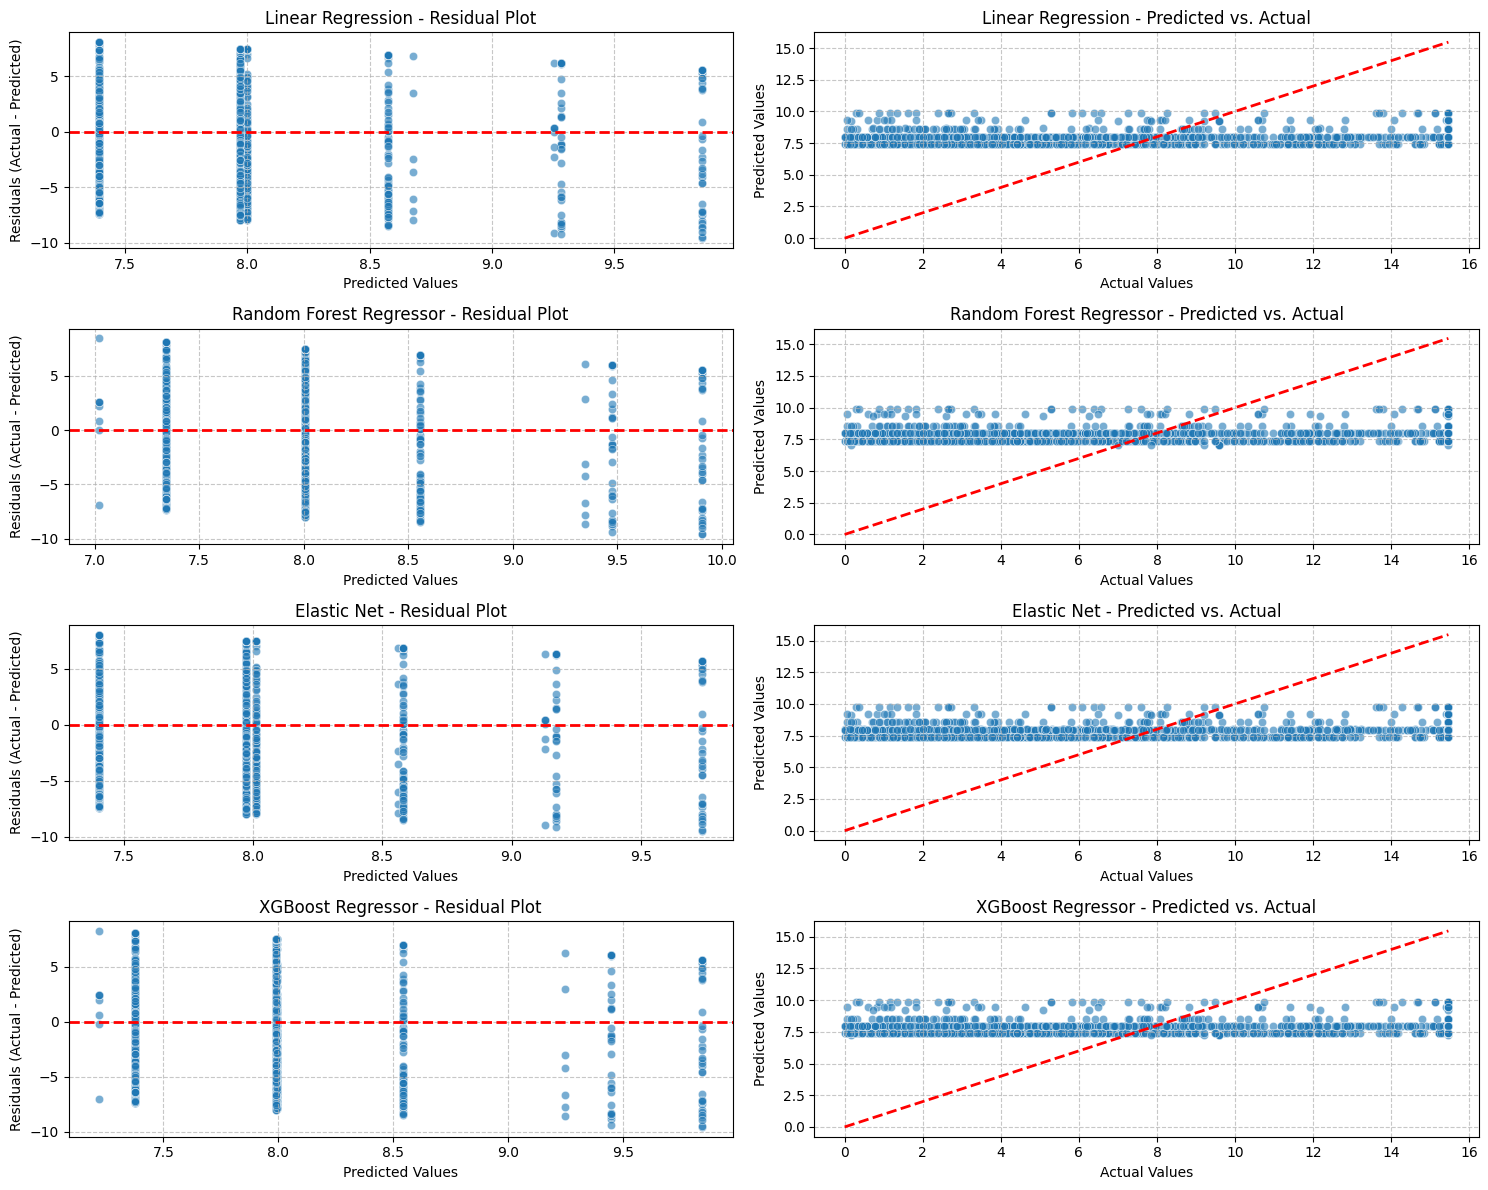

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a list of models and their predictions for the plots
regression_models_to_plot = {
    "Linear Regression": y_pred_linear_reg,
    "Random Forest Regressor": y_pred_rf_reg,
    "Elastic Net": y_pred_elastic_net,
    "XGBoost Regressor": y_pred_xgb_reg
}

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

plot_idx = 0
for model_name, y_pred in regression_models_to_plot.items():
    # Residual Plot
    residuals = y_test_reg - y_pred
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[plot_idx])
    axes[plot_idx].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[plot_idx].set_title(f'{model_name} - Residual Plot')
    axes[plot_idx].set_xlabel('Predicted Values')
    axes[plot_idx].set_ylabel('Residuals (Actual - Predicted)')
    axes[plot_idx].grid(True, linestyle='--', alpha=0.7)
    plot_idx += 1

    # Predicted vs. Actual Plot
    sns.scatterplot(x=y_test_reg, y=y_pred, alpha=0.6, ax=axes[plot_idx])
    axes[plot_idx].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
    axes[plot_idx].set_title(f'{model_name} - Predicted vs. Actual')
    axes[plot_idx].set_xlabel('Actual Values')
    axes[plot_idx].set_ylabel('Predicted Values')
    axes[plot_idx].grid(True, linestyle='--', alpha=0.7)
    plot_idx += 1

plt.tight_layout()
plt.show()


## SECTION 5 - BUSINESS IMPACT ANALYSIS

In [ ]:
print("Starting Business Impact Analysis...")

# 1. Prepare Data for Business Impact Analysis
test_data_analysis = X_test_cls_ut.copy()
test_data_analysis['delayed'] = y_test_cls
test_data_analysis['mins'] = df['mins'].loc[test_data_analysis.index]

print("DataFrame 'test_data_analysis' created successfully.")


# 2. Predict delay probabilities to identify high-risk orders
X_test_cls_transformed_for_proba = preprocessor_cls.transform(X_test_cls_ut)
test_data_analysis['predicted_proba_delayed'] = nb_model.predict_proba(X_test_cls_transformed_for_proba)[:, 1]

# Identify the top 10% highest risk orders
top_10_percent_count = int(len(test_data_analysis) * 0.1)
top_10_percent_risk = test_data_analysis.nlargest(top_10_percent_count, 'predicted_proba_delayed')

print(f"Predicted probabilities added and top {top_10_percent_count} high-risk orders identified.")

# 3. Calculate Baseline Metrics (Entire Test Set)
print("\nCalculating baseline metrics for the entire test set...")

baseline_delayed_rate = test_data_analysis['delayed'].mean() * 100
baseline_avg_delay_mins = test_data_analysis[test_data_analysis['delayed'] == 1]['mins'].mean()

# 4. Calculate Metrics for Top 10% Risk Group (No Intervention)
print("\nCalculating metrics for the top 10% highest risk orders without intervention...")

top_10_delayed_rate_no_intervention = top_10_percent_risk['delayed'].mean() * 100
top_10_avg_delay_mins_no_intervention = top_10_percent_risk[top_10_percent_risk['delayed'] == 1]['mins'].mean()

# 6. Summarize Business Impact
print("\n" + "="*40)
print("BUSINESS IMPACT ANALYSIS SUMMARY")
print("="*40)

print(f"\nBaseline (Entire Test Set):")
print(f"  Delayed Rate: {baseline_delayed_rate:.2f}%")
print(f"  Average Delay Minutes (for delayed orders): {baseline_avg_delay_mins:.2f} mins")

print(f"\nTop 10% Highest Risk Orders (NO Intervention):")
print(f"  Delayed Rate: {top_10_delayed_rate_no_intervention:.2f}%")
print(f"  Average Delay Minutes (for delayed orders): {top_10_avg_delay_mins_no_intervention:.2f} mins")


Starting Business Impact Analysis...
DataFrame 'test_data_analysis' created successfully.
Predicted probabilities added and top 744 high-risk orders identified.

Calculating baseline metrics for the entire test set...

Calculating metrics for the top 10% highest risk orders without intervention...

BUSINESS IMPACT ANALYSIS SUMMARY

Baseline (Entire Test Set):
  Delayed Rate: 22.43%
  Average Delay Minutes (for delayed orders): 18.12 mins

Top 10% Highest Risk Orders (NO Intervention):
  Delayed Rate: 26.48%
  Average Delay Minutes (for delayed orders): 19.24 mins


In [ ]:
print("Starting Business Impact Analysis...")

# 1. Prepare Data for Business Impact Analysis
test_data_analysis = X_test_cls_ut.copy()
test_data_analysis['delayed'] = y_test_cls
test_data_analysis['mins'] = df['mins'].loc[test_data_analysis.index]

print("DataFrame 'test_data_analysis' created successfully.")


# 2. Predict delay probabilities to identify high-risk orders
X_test_cls_transformed_for_proba = preprocessor_cls.transform(X_test_cls_ut)
test_data_analysis['predicted_proba_delayed'] = knn_model.predict_proba(X_test_cls_transformed_for_proba)[:, 1]

# Identify the top 10% highest risk orders
top_10_percent_count = int(len(test_data_analysis) * 0.1)
top_10_percent_risk = test_data_analysis.nlargest(top_10_percent_count, 'predicted_proba_delayed')

print(f"Predicted probabilities added and top {top_10_percent_count} high-risk orders identified.")

# 3. Calculate Baseline Metrics (Entire Test Set)
print("\nCalculating baseline metrics for the entire test set...")

baseline_delayed_rate = test_data_analysis['delayed'].mean() * 100
baseline_avg_delay_mins = test_data_analysis[test_data_analysis['delayed'] == 1]['mins'].mean()

# 4. Calculate Metrics for Top 10% Risk Group (No Intervention)
print("\nCalculating metrics for the top 10% highest risk orders without intervention...")

top_10_delayed_rate_no_intervention = top_10_percent_risk['delayed'].mean() * 100
top_10_avg_delay_mins_no_intervention = top_10_percent_risk[top_10_percent_risk['delayed'] == 1]['mins'].mean()

# 6. Summarize Business Impact
print("\n" + "="*40)
print("BUSINESS IMPACT ANALYSIS SUMMARY")
print("="*40)

print(f"\nBaseline (Entire Test Set):")
print(f"  Delayed Rate: {baseline_delayed_rate:.2f}%")
print(f"  Average Delay Minutes (for delayed orders): {baseline_avg_delay_mins:.2f} mins")

print(f"\nTop 10% Highest Risk Orders (NO Intervention):")
print(f"  Delayed Rate: {top_10_delayed_rate_no_intervention:.2f}%")
print(f"  Average Delay Minutes (for delayed orders): {top_10_avg_delay_mins_no_intervention:.2f} mins")

Starting Business Impact Analysis...
DataFrame 'test_data_analysis' created successfully.
Predicted probabilities added and top 744 high-risk orders identified.

Calculating baseline metrics for the entire test set...

Calculating metrics for the top 10% highest risk orders without intervention...

BUSINESS IMPACT ANALYSIS SUMMARY

Baseline (Entire Test Set):
  Delayed Rate: 22.43%
  Average Delay Minutes (for delayed orders): 18.12 mins

Top 10% Highest Risk Orders (NO Intervention):
  Delayed Rate: 23.66%
  Average Delay Minutes (for delayed orders): 17.83 mins


Feature Importances

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- Feature Importance Analysis ---")

def plot_feature_importances(model, preprocessor, numerical_features, categorical_features, title):
    # Get feature names after one-hot encoding
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
    all_feature_names = numerical_features + ohe_feature_names

    # Get feature importances
    # Check if the model has feature_importances_
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        print(f"Skipping feature importance plot for {title}: Model does not have 'feature_importances_'.")
        return

    # Create a DataFrame for better visualization
    feature_importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print(f"\nTop 10 Features for {title}:")
    display(feature_importance_df.head(10))

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
    plt.title(f'Top 10 Feature Importances - {title}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


# --- Classification Model Feature Importance (Random Forest Classifier) ---
print("Calculating feature importances for Random Forest Classifier...")
# Re-extracting feature names for classification to ensure correctness
numerical_features_cls = X_train_cls_ut.select_dtypes(include=np.number).columns.tolist()
categorical_features_cls = X_train_cls_ut.select_dtypes(include='object').columns.tolist()

plot_feature_importances(
    rf_model, # Random Forest Classifier
    preprocessor_cls,
    numerical_features_cls,
    categorical_features_cls,
    "Classification (Random Forest)"
)

# --- Regression Model Feature Importance (Random Forest Regressor) ---
print("Calculating feature importances for Random Forest Regressor...")
# Re-extracting feature names for regression to ensure correctness
numerical_features_reg = X_train_reg_ut.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = X_train_reg_ut.select_dtypes(include='object').columns.tolist()

plot_feature_importances(
    rf_reg_model, # Random Forest Regressor
    preprocessor_reg,
    numerical_features_reg,
    categorical_features_reg,
    "Regression (Random Forest Regressor)"
)

# --- KNN Model does not have direct feature importances ---


--- Feature Importance Analysis ---
Calculating feature importances for Random Forest Classifier...


ValueError: All arrays must be of the same length

# Task
*   **Update Feature Importance Plotting Function**: Modify the `plot_feature_importances` function to correctly retrieve the names of all features after they have been transformed by the `ColumnTransformer`. This involves using `preprocessor.get_feature_names_out()` to ensure the feature names match the `feature_importances_` array in length and order.
*   **Re-run Classification Feature Importance**: Execute the updated `plot_feature_importances` function for the Random Forest Classifier (`rf_model`) and its corresponding preprocessor (`preprocessor_cls`) to visualize the top features for delay classification.
*   **Re-run Regression Feature Importance**: Execute the updated `plot_feature_importances` function for the Random Forest Regressor (`rf_reg_model`) and its corresponding preprocessor (`preprocessor_reg`) to visualize the top features for predicting delay minutes.

## Update Feature Importance Plotting Function

### Subtask:
Modify the `plot_feature_importances` function to correctly retrieve the names of all features after they have been transformed by the `ColumnTransformer`.


**Reasoning**:
The subtask requires modifying the `plot_feature_importances` function to correctly get feature names from the `ColumnTransformer`. I will update the function's definition to use `preprocessor.get_feature_names_out()` directly, which is the correct way to retrieve all feature names after preprocessing, then re-run the relevant code.




--- Feature Importance Analysis ---
Calculating feature importances for Random Forest Classifier...

Top 10 Features for Classification (Random Forest):


,Feature,Importance
1,num__is_rush_hour,0.439164
7,cat__is_modified?_Yes,0.216205
6,cat__is_modified?_No,0.167784
3,cat__is_food_order?_No,0.095696
4,cat__is_food_order?_Yes,0.081150
0,num__is_weekend,0.000000
2,cat__country_code_MA,0.000000
5,cat__order_status_SUCCESS,0.000000


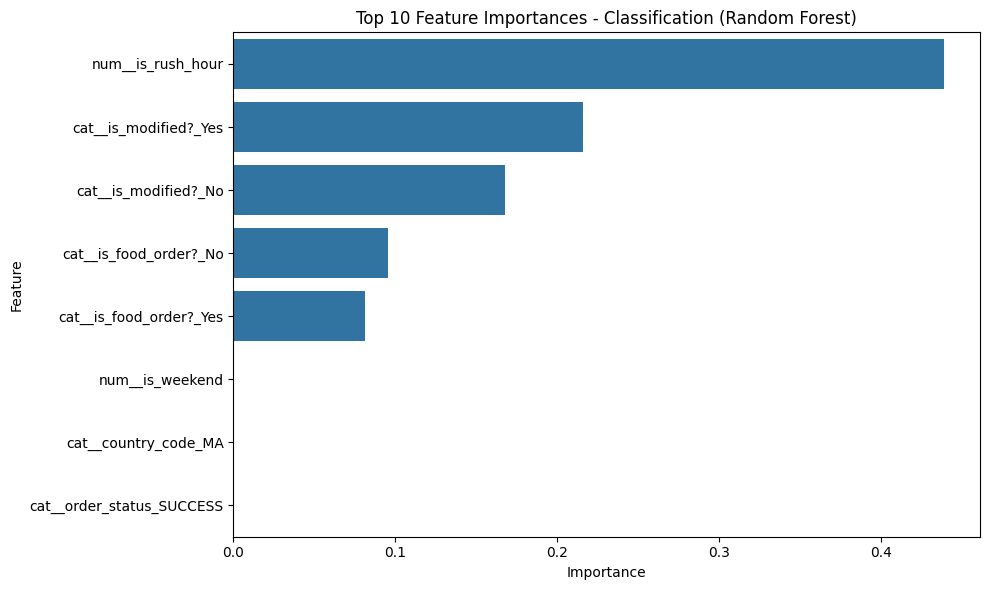

Calculating feature importances for Random Forest Regressor...

Top 10 Features for Regression (Random Forest Regressor):


,Feature,Importance
7,cat__is_modified?_Yes,0.371376
1,num__is_rush_hour,0.322451
3,cat__is_food_order?_No,0.264625
4,cat__is_food_order?_Yes,0.027357
6,cat__is_modified?_No,0.014191
0,num__is_weekend,0.000000
2,cat__country_code_MA,0.000000
5,cat__order_status_SUCCESS,0.000000


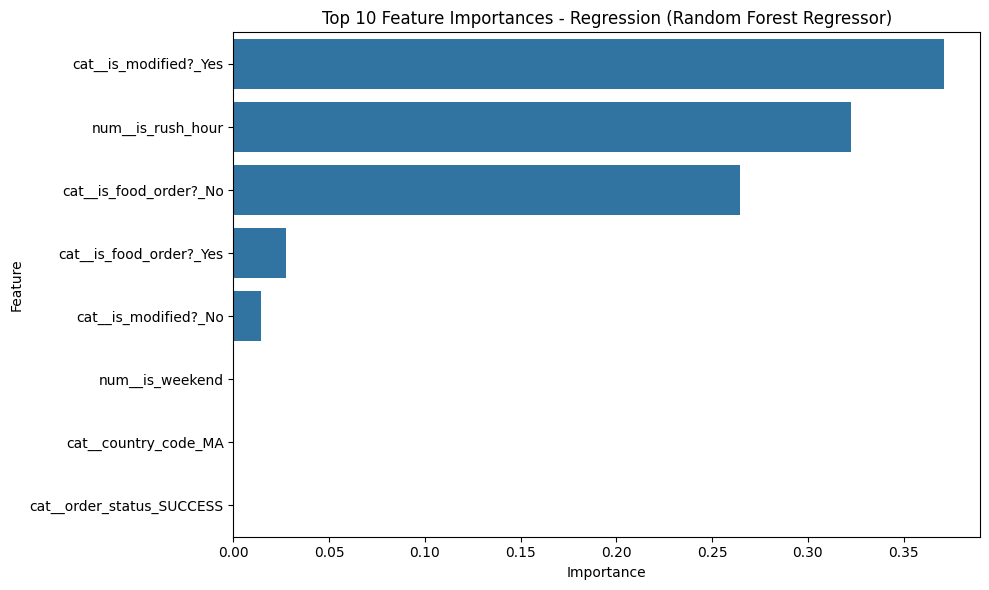

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- Feature Importance Analysis ---")

def plot_feature_importances(model, preprocessor, numerical_features, categorical_features, title):
    # Get feature names after one-hot encoding
    # The previous approach of combining numerical and OHE names was incorrect for `get_feature_names_out`.
    # Using preprocessor.get_feature_names_out() directly correctly handles all transformed feature names.
    all_feature_names = preprocessor.get_feature_names_out().tolist()

    # Get feature importances
    # Check if the model has feature_importances_
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        print(f"Skipping feature importance plot for {title}: Model does not have 'feature_importances_'.")
        return

    # Create a DataFrame for better visualization
    feature_importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print(f"\nTop 10 Features for {title}:")
    display(feature_importance_df.head(10))

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
    plt.title(f'Top 10 Feature Importances - {title}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


# --- Classification Model Feature Importance (Random Forest Classifier) ---
print("Calculating feature importances for Random Forest Classifier...")
# Re-extracting feature names for classification to ensure correctness
numerical_features_cls = X_train_cls_ut.select_dtypes(include=np.number).columns.tolist()
categorical_features_cls = X_train_cls_ut.select_dtypes(include='object').columns.tolist()

plot_feature_importances(
    rf_model, # Random Forest Classifier
    preprocessor_cls,
    numerical_features_cls,
    categorical_features_cls,
    "Classification (Random Forest)"
)

# --- Regression Model Feature Importance (Random Forest Regressor) ---
print("Calculating feature importances for Random Forest Regressor...")
# Re-extracting feature names for regression to ensure correctness
numerical_features_reg = X_train_reg_ut.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = X_train_reg_ut.select_dtypes(include='object').columns.tolist()

plot_feature_importances(
    rf_reg_model, # Random Forest Regressor
    preprocessor_reg,
    numerical_features_reg,
    categorical_features_reg,
    "Regression (Random Forest Regressor)"
)

# --- KNN Model does not have direct feature importances ---

## Summary:

### Data Analysis Key Findings
*   The `plot_feature_importances` function was successfully updated to accurately retrieve transformed feature names by utilizing `preprocessor.get_feature_names_out().tolist()`. This resolved previous issues with feature name misalignment.
*   Feature importance plots and top 10 feature lists were successfully generated for both the Random Forest Classifier (for delay classification) and the Random Forest Regressor (for predicting delay minutes), demonstrating the correct functionality of the updated plotting function.

### Insights or Next Steps
*   The improved feature importance visualization now provides a reliable way to understand which features are most influential for both delay classification and delay duration prediction, enabling more informed feature selection or engineering.
*   Analyze the specific top features identified by both models to understand common drivers of flight delays and potential differences between factors affecting delay occurrence versus delay magnitude.
